# Tarea Semanal 1: Análisis de Filtro Pasa-todo de 1er Orden
*Alumno: Contreras Juan Manuel*  
*Materia: Teoría de Circuitos II*  
*Institución: UTN FRBA*  

<img src="./img/circuito_01.png" width="500">

## 1. Obtención Analítica de la Función de Transferencia

Para hallar la transferencia $T(s) = \frac{V_2}{V_1}$, analizamos el circuito utilizando el método de nodos y considerando un amplificador operacional ideal ($V_+ = V_- = V_a$).

### Análisis por Admitancias ($Y$)

Planteamos las ecuaciones de corrientes en los nodos principales:

* **Nodo Inversor ($V_-$):**
  $$V_a (Y_{R1} + Y_{R2}) - V_1 Y_{R1} - V_2 Y_{R2} = 0$$

* **Nodo No Inversor ($V_+$):**
  $$V_a (Y_C + Y_{R3}) - V_1 Y_C = 0 \implies V_a = V_1 \frac{Y_C}{Y_C + Y_{R3}}$$

### Desarrollo Algebraico

Sustituimos la expresión de $V_a$ en la primera ecuación:
$$V_1 \left( \frac{Y_C (Y_{R1} + Y_{R2})}{Y_C + Y_{R3}} - Y_{R1} \right) = V_2 Y_{R2}$$

Despejando la relación $\frac{V_2}{V_1}$:
$$\frac{V_2}{V_1} = \frac{Y_C (Y_{R1} + Y_{R2}) - Y_{R1} (Y_C + Y_{R3})}{Y_{R2} (Y_C + Y_{R3})}$$

Considerando el caso de ratio unitario ($R_1 = R_2 \implies Y_{R1} = Y_{R2}$), simplificamos la expresión:
$$T(s) = \frac{sC \cdot 2 Y_{R1} - Y_{R1} (sC + Y_{R3})}{Y_{R1} (sC + Y_{R3})}$$
$$T(s) = \frac{sC - Y_{R3}}{sC + Y_{R3}}$$

Sustituyendo $Y_{R3} = \frac{1}{R_3}$:
$$\therefore T(s) = \frac{s - \frac{1}{R_3 C}}{s + \frac{1}{R_3 C}}$$

---

## 2. Análisis de Respuesta en Frecuencia (Módulo y Fase)

Para entender el comportamiento del filtro, evaluamos la función de transferencia normalizada en el eje imaginario ($s = j\omega$):

$$T(j\omega) = \frac{j\omega - 1}{j\omega + 1}$$

### A. Análisis de Módulo
El módulo de la transferencia se calcula como el cociente de los módulos del numerador y denominador:

$$|T(j\omega)| = \frac{|j\omega - 1|}{|j\omega + 1|} = \frac{\sqrt{\omega^2 + (-1)^2}}{\sqrt{\omega^2 + 1^2}} = \frac{\sqrt{\omega^2 + 1}}{\sqrt{\omega^2 + 1}} = 1$$

Como $|T(j\omega)| = 1$ para todo valor de $\omega$, la ganancia en decibeles es:
$$|T(j\omega)|_{dB} = 20 \cdot \log_{10}(1) = 0 \text{ dB}$$

### B. Análisis Asintótico de Fase
La fase total del sistema está dada por la fase del numerador menos la fase del denominador:
$$\phi(\omega) = \phi(j\omega - 1) - \phi(j\omega + 1)$$

Analizamos los casos extremos y el punto de corte:

1. **Bajas Frecuencias ($\omega \to 0$):**
   * El capacitor $C_1$ se comporta como un circuito abierto.
   * $\phi(0) = \phi(-1) - \phi(1) = 180 - 0 = 180$.

2. **Frecuencia de Corte ($\omega = 1$):**
   * La reactancia del capacitor iguala a la resistencia ($X_{C1} = R_3$).
   * $\phi(1) = \phi(j - 1) - \phi(j + 1) = 135 - 45 = 90$.

3. **Altas Frecuencias ($\omega \to \infty$):**
   * El capacitor $C_1$ se comporta como un cortocircuito.
   * $\phi(\infty) = \phi(j\omega) - \phi(j\omega) = 90 - 90 = 0$.

---

## 3. Normalización
Definimos las normas para obtener la transferencia normalizada:
* **Norma de frecuencia:** $\Omega_\omega = \frac{1}{R_3 C_1}$
* **Norma de impedancia:** $\Omega_z = R_3$

Sustituyendo $s_n = \frac{s}{\Omega_\omega}$, la función de transferencia normalizada resulta:

$$T_n(s) = \frac{s - 1}{s + 1}$$

---

## 4. Simulación
Utilizamos el siguiente bloque de código para verificar la expresión hallada:

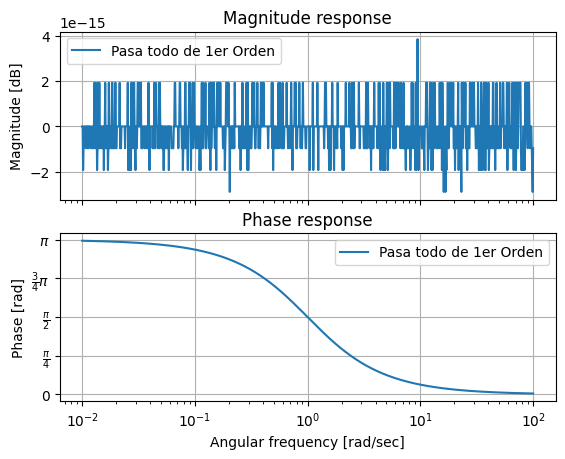

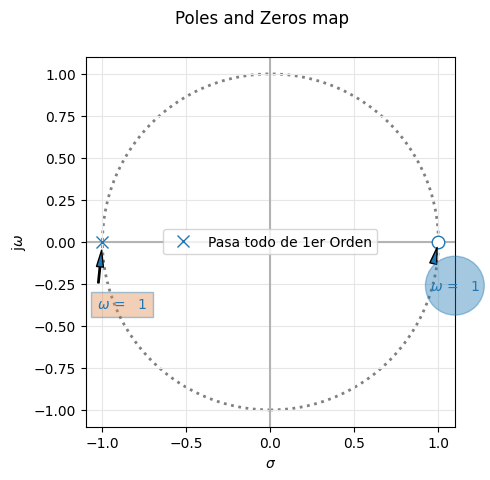

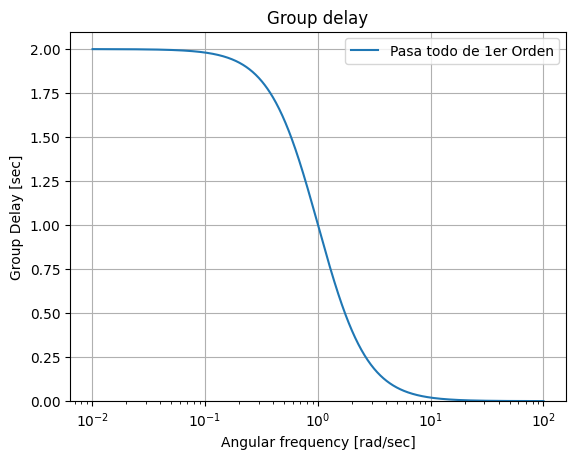

In [1]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
from pytc2.sistemas_lineales import analyze_sys

# Definición de la transferencia
num = np.array([1, -1])
den = np.array([1, 1])
tf_n = sig.TransferFunction(num, den)

# Simulación
analyze_sys([tf_n], sys_name='Pasa todo de 1er Orden')

plt.show()

---

## 5. Simulación Circuital en LTspice

Para validar la función de transferencia obtenida, se simuló la red normalizada en LTspice utilizando los siguientes parámetros:

* **Componentes Normalizados:** $R_1 = R_2 = R_3 = 1 \Omega$, $C_1 = 1 F$.
* **Configuración de Simulación:** `.ac dec 100 0.01 100`.
* **Modelo de OPAMP:** UniversalOpamp2.

### Resultados Obtenidos
La simulación confirma el comportamiento de un filtro pasa-todo:
1. El módulo se mantiene constante en $0\ dB$.
2. La fase presenta un desplazamiento que inicia en 180 y termina en 0, pasando por 90 en la frecuencia de corte normalizada ($f_c = \frac{1}{2\pi} \approx 159\  mHz$).  

![Gráfico de Bode](./img/bode_plot.png)  

---